# A tour of PEAL: find and fix a shortcut on Waterbirds

This notebook walks through the whole PEAL workflow **with the library's own building blocks** — config
classes and factories — so that every step shows which object does what:

| step | what happens | PEAL objects |
|---|---|---|
| 1 | load a dataset (Waterbirds downloads itself) | `DataConfig`, `get_datasets`, `WaterbirdsDataset` |
| 2 | train the classifier we want to audit: a DINOv3 linear probe | `PredictorConfig`, `TrainingConfig`, `TaskConfig`, `ModelTrainer` |
| 3 | load a pretrained generator that can edit images in CLIP space | `RAEDiffusionAutoencoderConfig`, `get_generator` |
| 4 | load a sparse dictionary of named CLIP concepts | `MSAEDecompositionConfig`, `get_sparse_dictionary` |
| 5 | let DiDAE find the concepts the classifier relies on | `DiDAEConfig`, `get_adaptor`, `DiDAE.run` |
| 6 | look at the ranked directions and their counterfactuals | files in the run directory |
| 7 | judge each direction: true class feature or spurious shortcut | a plain dict of verdicts |
| 8 | correct the classifier by refitting only its last layer (DFR) | the predictor's `get_last_layer()` |

**Why Waterbirds?** Landbirds are photographed mostly on land and waterbirds mostly on water, so a
classifier can get most training images right by looking at the *background*. Waterbirds records the
background (`place`) of every image, which lets us measure the shortcut (accuracy per bird x
background group) and check whether DiDAE finds it.

**Every step has two options.** *Option A* is the default walkthrough and runs as is. *Option B* shows
where your own data, model, generator or verdicts go; switch it on with the flag in that cell. Steps
marked *optional* can be skipped when you bring your own pieces.

**Runtime** on one GPU (measured on an NVIDIA GB10): about 45 minutes in total: ~5 min download,
~9 min probe training, ~22 min DiDAE, a few minutes for the rest. Steps 2 and 5 reuse their results
when you run the notebook again (`REUSE = True`).

## 0. Setup

PEAL reads three environment variables: `PEAL_DATA` (datasets), `PEAL_RUNS` (models and runs) and,
for the representation-autoencoder generator used below, `PEAL_RAE_WEIGHTS` (where its pretrained
weights come from; `hf://...` downloads them from Hugging Face on first use). Every PEAL entry point
expects the repository root as working directory.

In [1]:
import os, sys, json, re, time
from pathlib import Path

REPO = Path.cwd() if (Path.cwd() / "peal").is_dir() else Path.cwd().parent
os.chdir(REPO)
sys.path.insert(0, str(REPO))

os.environ.setdefault("PEAL_DATA", str(Path.home() / "peal_data" / "datasets"))
os.environ.setdefault("PEAL_RUNS", str(Path.home() / "peal_data" / "runs"))
os.environ.setdefault("PEAL_RAE_WEIGHTS", "hf://sidney1505/peal-rae-clip-imagenet")
DATA, RUNS = Path(os.environ["PEAL_DATA"]), Path(os.environ["PEAL_RUNS"])
WORK = RUNS / "waterbirds_tour"          # everything this notebook writes
REUSE = True                             # reuse a trained probe / finished DiDAE run if present

import numpy as np, torch
import matplotlib.pyplot as plt
import io
from IPython.display import display, Image as PNG

def show(fig):
    # render as PNG: parts of PEAL switch matplotlib to its non-interactive 'Agg'
    # backend while they plot, after which plt.show() would print nothing
    buf = io.BytesIO(); fig.savefig(buf, format="png", dpi=90, bbox_inches="tight"); plt.close(fig)
    display(PNG(buf.getvalue()))
print("repository:", REPO)
print("PEAL_DATA:", DATA, "| PEAL_RUNS:", RUNS)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none (this will be very slow)")

repository: /opt/peal
PEAL_DATA: /data/datasets | PEAL_RUNS: /data/notebook_runs
GPU: NVIDIA GB10


## 1. Data: `DataConfig` → `get_datasets`

A `DataConfig` describes a dataset: which class reads it (`dataset_class`, looked up in PEAL's
registry), where it lives, the image size the model sees, the normalization and which metadata
columns exist. `get_datasets` turns it into the train / validation / test datasets.

`WaterbirdsDataset` **downloads the data in its constructor** when `<dataset_path>/data.csv` is
missing: the Waterbirds images (~450 MB, from the group-DRO authors at Stanford) and the CUB
segmentation masks (from Caltech), about 1.1 GB on disk. Its `metadata.csv` becomes `data.csv` with
the columns `y` (0 landbird, 1 waterbird), `split` (the official 0/1/2 split, used because
`split=[]`) and `place` (0 land, 1 water background).

### Option A (default): Waterbirds

In [2]:
from peal.data.interfaces import DataConfig
from peal.data.dataset_factory import get_datasets

data_config = DataConfig(
    dataset_class="WaterbirdsDataset",           # registry name of the dataset class
    dataset_path=str(DATA / "waterbirds"),       # downloaded here if missing
    input_type="image",
    output_type="singleclass",                   # one label per image
    input_size=[3, 256, 256],                    # what the classifier sees
    output_size=[2],                             # two classes
    x_selection="img_filename",                  # data.csv column with the image paths
    confounding_factors=["y", "place"],          # metadata PEAL keeps track of
    split=[],                                    # [] = use the "split" column (official splits)
    normalization=None,                          # None = pixels in [0, 1]
)
t0 = time.time()
train_set, val_set, test_set = get_datasets(data_config)
print(f"{len(train_set)} train / {len(val_set)} val / {len(test_set)} test images ({time.time() - t0:.0f} s)")
print("metadata columns:", train_set.attributes)

Loading config from config_name='DataConfig' input_type='image' output_type='singleclass' input_size=[3, 256, 256] output_size=[2] dataset_path='/data/datasets/waterbirds' dataset_origin_path=None num_samples=None dataset_class='WaterbirdsDataset' split=[] has_hints=False normalization=None invariances=[] output_split=None downsize=None confounding_factors=['y', 'place'] foreground=None background=None confounder_probability=None full_confounder_config=None class_ratios=None seed=0 label_noise=None set_negative_to_zero=True font_path=None delimiter=',' crop_size=None inverse=None label_rel_path='data.csv' x_selection='img_filename' in_memory=False spray_label_file=None spray_groups_balanced=False generator=None diffusion_augmented=False sampling_time_fraction=0.3 num_discretization_steps=20 batch_wise_augmentation=True tabular_preprocessing=None


instantiate waterbirds dataset!


instantiate waterbirds dataset!


instantiate waterbirds dataset!


4795 train / 1199 val / 5794 test images (0 s)
metadata columns: ['y', 'split', 'place', 'place_filename']


### Option B: your own images

Put your images anywhere under one folder and write a `data.csv` next to them: first column the image
path relative to `<dataset_path>/<x_selection>`, then one column per label or attribute. The generic
`Image2MixedDataset` reads that layout; `split=[0.8, 0.9]` splits it 80 / 10 / 10 at random.
Set `normalization` to what *your* model expects (e.g. ImageNet mean/std as `[[...], [...]]`).

In [3]:
USE_OWN_DATA = False
if USE_OWN_DATA:
    data_config = DataConfig(
        dataset_class="Image2MixedDataset",
        dataset_path="/path/to/my_dataset",       # contains data.csv and imgs/...
        input_type="image", output_type="singleclass",
        input_size=[3, 224, 224], output_size=[2],
        x_selection="imgs", confounding_factors=["Label"],
        split=[0.8, 0.9], normalization=None,
    )
    train_set, val_set, test_set = get_datasets(data_config)

**Which columns become the target** is decided by a `TaskConfig`: `y_selection` names the metadata
columns. For training we will use `["y"]`; here we ask for `["y", "place"]` to see the four groups.
(The default loss of a `TaskConfig` is cross-entropy, which allows only one target column, so this
evaluation-only view uses an `l2` criterion.)

Loading config from config_name='DataConfig' input_type='image' output_type='singleclass' input_size=[3, 256, 256] output_size=[2] dataset_path='/data/datasets/waterbirds' dataset_origin_path=None num_samples=None dataset_class='WaterbirdsDataset' split=[] has_hints=False normalization=None invariances=[] output_split=None downsize=None confounding_factors=['y', 'place'] foreground=None background=None confounder_probability=None full_confounder_config=None class_ratios=None seed=0 label_noise=None set_negative_to_zero=True font_path=None delimiter=',' crop_size=None inverse=None label_rel_path='data.csv' x_selection='img_filename' in_memory=False spray_label_file=None spray_groups_balanced=False generator=None diffusion_augmented=False sampling_time_fraction=0.3 num_discretization_steps=20 batch_wise_augmentation=True tabular_preprocessing=None


instantiate waterbirds dataset!


instantiate waterbirds dataset!


instantiate waterbirds dataset!


                    train images
landbird on land            3498
landbird on water            184
waterbird on land             56
waterbird on water          1057


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.010937217..1.0000001].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000002].


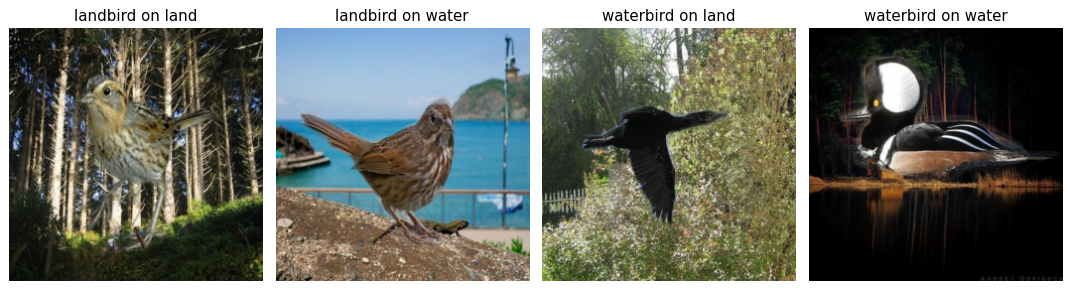

In [4]:
from peal.architectures.interfaces import TaskConfig

group_task = TaskConfig(criterions={"l2": 1.0}, output_type="multiclass", output_channels=2,
                        y_selection=["y", "place"])
_, _, test_groups = get_datasets(data_config, task_config=group_task)

GROUP_NAMES = {(0, 0): "landbird on land", (0, 1): "landbird on water",
               (1, 0): "waterbird on land", (1, 1): "waterbird on water"}
# counting the training groups straight from data.csv is quicker than reading every image
import pandas as pd
meta = pd.read_csv(DATA / "waterbirds" / "data.csv")
counts = meta[meta.split == 0].groupby(["y", "place"]).size()
print(pd.DataFrame({"train images": {GROUP_NAMES[k]: int(v) for k, v in counts.items()}}))

fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
for ax, (key, name) in zip(axes, GROUP_NAMES.items()):
    idx = next(i for i in range(0, len(test_groups), 7) if tuple(test_groups[i][1].int().tolist()) == key)
    ax.imshow(test_groups[idx][0].permute(1, 2, 0)); ax.set_title(name); ax.axis("off")
plt.tight_layout(); show(fig)

## 2. The classifier: `PredictorConfig` → `ModelTrainer`  *(optional: skip with Option B if you have a model)*

We train a **DINOv3 ViT-L/16 linear probe**: the pretrained backbone stays frozen
(`only_last_layer=True`) and only a linear head on the CLS feature is learned. The architecture string
`torchvision_dino_v3` is resolved by PEAL's predictor factory; the gated Hugging Face repo is tried
first and the public `timm` weights are used when you have no access.

`continue_training=True` matters here: without it `fit()` would re-initialize the pretrained backbone.
The model is saved as `<model_path>/model.cpl` (a pickled `torch.nn.Module`) together with its
`config.yaml`.

### Option A (default): train the DINOv3 probe

In [5]:
from peal.training.interfaces import PredictorConfig, TrainingConfig
from peal.training.trainers import ModelTrainer

train_task = TaskConfig(criterions={"ce": 1.0}, output_type="singleclass", output_channels=2, y_selection=["y"])
probe_config = PredictorConfig(
    architecture="torchvision_dino_v3",
    data=data_config,
    task=train_task,
    training=TrainingConfig(
        max_epochs=4, steps_per_epoch=100,       # 400 optimizer steps: a linear head needs little
        train_batch_size=32, val_batch_size=32, test_batch_size=64,
        learning_rate=1e-3, optimizer="adamw", dropout=0.0,
    ),
    model_path=str(WORK / "dinov3_linear_probe"),
    only_last_layer=True,
    continue_training=True,
)
student_path = Path(probe_config.model_path) / "model.cpl"
if REUSE and student_path.exists():
    print("reusing", student_path)
else:
    t0 = time.time()
    ModelTrainer(probe_config).fit(continue_training=True)
    print(f"trained in {time.time() - t0:.0f} s -> {student_path}")

reusing /data/notebook_runs/waterbirds_tour/dinov3_linear_probe/model.cpl


### Option B: your own model

`get_predictor` loads a `.cpl` (pickled torch module) or an `.onnx` file (converted to torch with
`onnx2torch`, or run with onnxruntime if that fails). Its outputs must be the two class logits in the
order of your labels, and it must expect exactly the images `data_config` produces.

In [6]:
USE_OWN_MODEL = False
if USE_OWN_MODEL:
    student_path = Path("/path/to/my_model.onnx")   # or .cpl

**The shortcut, measured.** `get_predictor` loads the model; we evaluate it per (bird, background)
group. A model that leans on the background is noticeably worse on the two groups where bird and
background disagree.

In [7]:
from torch.utils.data import DataLoader
from peal.architectures.predictors import get_predictor

student, _ = get_predictor(str(student_path), device="cuda")
student.eval()

def predict_features(model, dataset, batch_size=64):
    # penultimate features, labels and backgrounds of a dataset built with group_task
    feats, ys, places = [], [], []
    for x, t in DataLoader(dataset, batch_size=batch_size, num_workers=4):
        with torch.no_grad():
            f, _ = model(x.cuda(), return_latents=True)
        feats.append(f.float().cpu()); ys.append(t[:, 0].long()); places.append(t[:, 1].long())
    return torch.cat(feats).numpy(), torch.cat(ys).numpy(), torch.cat(places).numpy()

def group_report(pred, y, place):
    accs = {name: float((pred[(y == k[0]) & (place == k[1])] == k[0]).mean()) for k, name in GROUP_NAMES.items()}
    return pd.DataFrame({"accuracy": accs}).T.assign(**{
        "overall": float((pred == y).mean()),
        "average group": float(np.mean(list(accs.values()))),
        "worst group": float(min(accs.values())),
    }).round(3)

F_test, y_test, place_test = predict_features(student, test_groups)
last = student.get_last_layer()
W_before = last.weight.detach().cpu().numpy()
b_before = last.bias.detach().cpu().numpy() if last.bias is not None else np.zeros(2)
before = group_report((F_test @ W_before.T + b_before).argmax(1), y_test, place_test)
before.index = ["before"]; before

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,landbird on land,landbird on water,waterbird on land,waterbird on water,overall,average group,worst group
before,0.999,0.898,0.802,0.96,0.933,0.915,0.802


## 3. The generator: `RAEDiffusionAutoencoderConfig` → `get_generator`

DiDAE edits images in the embedding space of a foundation model and needs a generator that turns an
edited embedding back into an image. PEAL ships a **representation autoencoder (RAE)** trained on
ImageNet: it is conditioned on the OpenAI CLIP ViT-L/14 image embedding and inverts a real image into
noise maps (edit-friendly DDPM inversion), so an edit keeps the rest of the image. Its weights are
public on Hugging Face.

We load the shipped config into its config class and change what matters for us: the dataset (in the
generator's normalization, pixels in [-1, 1]) and where it may write files. The sampler settings
(25 DDPM steps, classifier-free guidance 3, bf16) come from the web demo's tuning on Waterbirds.

### Option A (default): the published ImageNet RAE

In [8]:
from peal.global_utils import load_yaml_config
from peal.generators.rae_diffusion_autoencoder import RAEDiffusionAutoencoderConfig
from peal.generators.generator_factory import get_generator

generator_config = load_yaml_config("configs/web_demo/imagenet_rae_clip_hf.yaml", RAEDiffusionAutoencoderConfig)
generator_config.data = data_config.model_copy(update={"normalization": [0.5, 0.5]})
generator_config.base_path = str(WORK / "rae_generator")
generator_config.weights = os.environ["PEAL_RAE_WEIGHTS"]
print("sampler:", generator_config.sampler, "| guidance:", generator_config.guidance_scale,
      "| bf16 sampling:", generator_config.sde_autocast)

generator = get_generator(generator_config, device="cuda")

Loading config from configs/web_demo/imagenet_rae_clip_hf.yaml


Config model provided and config_data is a dict. Loading config data into the config model.


Loading config from {'dataset_class': 'Image2MixedDataset', 'dataset_path': None, 'num_samples': None, 'input_type': 'image', 'input_size': [3, 256, 256], 'output_type': 'singleclass', 'output_size': [2], 'downsize': 'Resize', 'x_selection': 'imgs', 'confounding_factors': ['Class'], 'normalization': [0.5, 0.5]}


Loading config from {'type': 'ddpm', 'num_steps': 25}


sampler: {'type': 'ddpm', 'num_steps': 25} | guidance: 3.0 | bf16 sampling: True
Loading config from generator_type='RAEDiffusionAutoencoder' category='generator' batch_size=16 current_fid=inf seed=0 base_path='/data/notebook_runs/waterbirds_tour/rae_generator' data=DataConfig(config_name='DataConfig', input_type='image', output_type='singleclass', input_size=[3, 256, 256], output_size=[2], dataset_path='/data/datasets/waterbirds', dataset_origin_path=None, num_samples=None, dataset_class='WaterbirdsDataset', split=[], has_hints=False, normalization=[0.5, 0.5], invariances=[], output_split=None, downsize=None, confounding_factors=['y', 'place'], foreground=None, background=None, confounder_probability=None, full_confounder_config=None, class_ratios=None, seed=0, label_noise=None, set_negative_to_zero=True, font_path=None, delimiter=',', crop_size=None, inverse=None, label_rel_path='data.csv', x_selection='img_filename', in_memory=False, spray_label_file=None, spray_groups_balanced=Fals

...

instantiate waterbirds dataset!


instantiate waterbirds dataset!


Loading pretrained decoder from /data/notebook_runs/hf_weights/sidney1505__peal-rae-clip-imagenet/decoder.pt


Loaded normalization stats from /data/notebook_runs/hf_weights/sidney1505__peal-rae-clip-imagenet/stats.pt
RAE: encoder=clipproj-vit-L, resolution=256, patch_size=14, hidden_size=1024, decoder_aux_mode=discard, num_aux_tokens=0


[RAEDiffusionAutoencoder] stage 2 loaded from /data/notebook_runs/hf_weights/sidney1505__peal-rae-clip-imagenet/stage2_ema.pt (ema); epoch=None step=None


### Option B: another generator

Any PEAL generator with `encode` / `decode` in the dictionary's embedding space works, e.g. your own
RAE trained with `train_generator.py` (see `configs/didae_experiments/generators/`). Load its
`config.yaml` the same way.

In [9]:
USE_OWN_GENERATOR = False
if USE_OWN_GENERATOR:
    generator_config = load_yaml_config("/path/to/my_generator/config.yaml", RAEDiffusionAutoencoderConfig)
    generator = get_generator(generator_config, device="cuda")

**Encode → decode round trip.** `encode` returns the CLIP embedding `z` (768-d) plus the noise
needed to reproduce the image; `decode` renders it back. This is what every counterfactual goes
through, with an edited `z`.

Loading config from config_name='DataConfig' input_type='image' output_type='singleclass' input_size=[3, 256, 256] output_size=[2] dataset_path='/data/datasets/waterbirds' dataset_origin_path=None num_samples=None dataset_class='WaterbirdsDataset' split=[] has_hints=False normalization=[0.5, 0.5] invariances=[] output_split=None downsize=None confounding_factors=['y', 'place'] foreground=None background=None confounder_probability=None full_confounder_config=None class_ratios=None seed=0 label_noise=None set_negative_to_zero=True font_path=None delimiter=',' crop_size=None inverse=None label_rel_path='data.csv' x_selection='img_filename' in_memory=False spray_label_file=None spray_groups_balanced=False generator=None diffusion_augmented=False sampling_time_fraction=0.3 num_discretization_steps=20 batch_wise_augmentation=True tabular_preprocessing=None


instantiate waterbirds dataset!


instantiate waterbirds dataset!


instantiate waterbirds dataset!


/opt/peal/peal/data/datasets.py:1988: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target = torch.tensor(


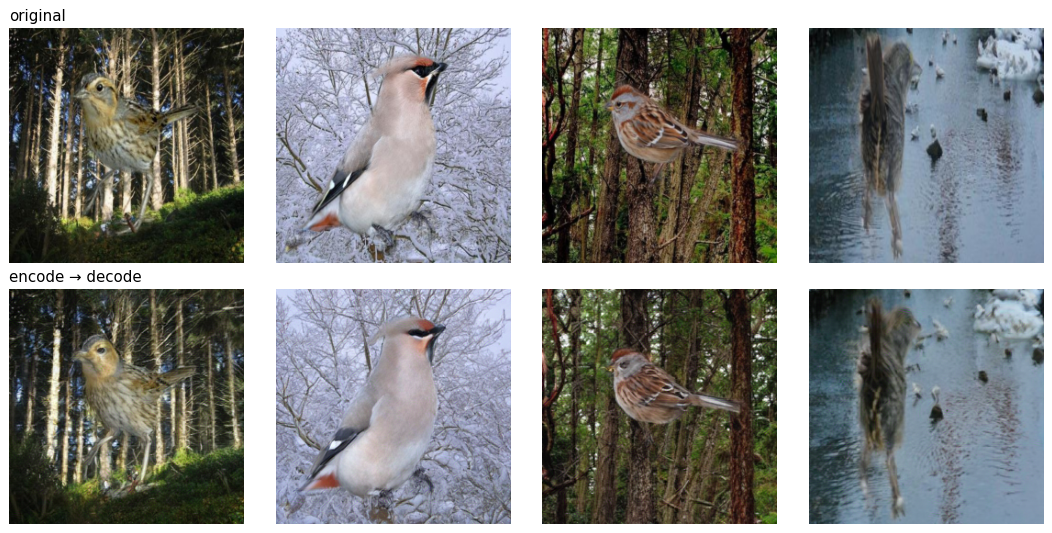

CLIP embedding: (4, 768)


In [10]:
_, _, gen_test = get_datasets(generator_config.data)
x = torch.stack([gen_test[i][0] for i in (0, 900, 3000, 5000)]).cuda()
with torch.no_grad():
    z, x_T, noise_maps = generator.encode(x, sample_type="ddpm_inv")
    x_rec = generator.decode((z, x_T, noise_maps), sample_type="ddpm_inv")
to_img = lambda t: (t.clamp(-1, 1) * 0.5 + 0.5).permute(1, 2, 0).float().cpu()
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    axes[0, i].imshow(to_img(x[i])); axes[1, i].imshow(to_img(x_rec[i]))
    axes[0, i].axis("off"); axes[1, i].axis("off")
axes[0, 0].set_title("original", loc="left"); axes[1, 0].set_title("encode → decode", loc="left")
plt.tight_layout(); show(fig)
print("CLIP embedding:", tuple(z.shape))

## 4. The dictionary: `MSAEDecompositionConfig` → `get_sparse_dictionary`

A sparse autoencoder over CLIP embeddings (Matryoshka SAE by Zaigrajew et al., public weights)
splits an embedding into 6144 sparse **concepts**, each with a name from a 20k-word vocabulary.
DiDAE's candidate directions are these concepts: switch one on or off (or one off and another on,
a *concept pair*) and see whether the classifier flips.

In [11]:
from peal.sparse_dictionaries.msae_decomposition import MSAEDecompositionConfig
from peal.sparse_dictionaries.sparse_dictionary_factory import get_sparse_dictionary

dictionary_config = load_yaml_config("configs/didae_experiments/sparse_dictionaries/msae_decomposition.yaml",
                                     MSAEDecompositionConfig)
dictionary = get_sparse_dictionary(dictionary_config, device="cuda")
vocabulary = dictionary.get_vocabulary()

codes = dictionary.encode(z)
for i in range(4):
    top = torch.topk(codes[i], 6)
    print(f"image {i}:", ", ".join(f"{vocabulary[k]} ({v:.1f})" for v, k in zip(top.values.tolist(), top.indices.tolist())))

Loading config from configs/didae_experiments/sparse_dictionaries/msae_decomposition.yaml


Config model provided and config_data is a dict. Loading config data into the config model.


Loading config from n_components=6144 dict_size=None sparse_dictionaries_type='MSAEDecomposition' category='sparse_dictionaries' base_path=None name=None run_name=None weights_path=None act_size=512 visualizations_per_component=100 weights_name='weights.npz' batch_size=1024 component_strings=None data=None fitted_on_encoder=None clip_model='clip:ViT-L/14' ckpt_url='https://huggingface.co/WolodjaZ/MSAE/resolve/main/ViT-L_14/centered/6144_768_TopKReLU_64_RW_False_False_0.0_cc3m_ViT-L~14_train_image_2905936_768.pth' interp_url='https://huggingface.co/WolodjaZ/MSAE/resolve/main/ViT-L_14/centered/Concept_Interpreter_6144_768_TopKReLU_64_RW_False_False_0.0_cc3m_ViT-L~14_train_image_2905936_768_disect_ViT-L~14_-1_text_20000_768.npy' local_dir='/tmp/msae_weights' vocab_filename='clip_disect_20k.txt' activation='TopKReLU_64' use_matryoshka=False lr=0.0005 epochs=20


[MSAE] Loaded MSAE with 6144 directions mapped to concepts.


image 0: scarborough (9.1), juvenile (8.1), birds (6.3), forest (5.3), playlists (5.1), rca (4.3)
image 1: birds (9.2), juvenile (6.8), snowmobile (4.7), hertfordshire (4.2), canary (4.1), avg (3.8)
image 2: birds (8.0), canary (6.3), juvenile (5.9), forest (5.0), ottawa (4.5), bild (4.4)
image 3: swimming (6.7), petrol (6.2), social (5.6), jumping (4.3), dogs (4.3), running (4.2)


The generator and dictionary were loaded here only to show them. DiDAE loads its own copies from the
same configs, so we free the GPU memory first.

In [12]:
del generator, dictionary, x, x_rec, z, x_T, noise_maps, codes
torch.cuda.empty_cache()

## 5. DiDAE: `DiDAEConfig` → `get_adaptor` → `run()`

An *adaptor* in PEAL is a workflow that takes a model (the *student*) and improves it with the help
of a *teacher*. DiDAE's workflow:

1. **distil** the student into a linear probe on the CLIP embedding (so directions can be tested
   cheaply in latent space);
2. **sweep** every dictionary concept (here: concept pairs) over a pool of training images and count
   *latent flips* — edits that flip the distilled probe;
3. **render** the edits of the top directions with the generator and classify the images with the
   real student: an *ambient flip* flips the student, a *verified flip* also shows the edited concept
   in the rendered image;
4. **rank** directions by verified flips and write collages;
5. ask the **teacher** whether each direction is a true class feature or a spurious one, and
   optionally correct the student.

Every setting lives in `DiDAEConfig`. The values below are the web demo's: concept pairs, edits up
to 3x the empirical range of a concept, 10 directions with at most 30 renders each.

The teacher here is PEAL's web-feedback teacher with an automatic verdict, which just lets the run
finish: we judge the directions ourselves in step 7, in this notebook. (With `teacher="cluster@8000"`
PEAL would instead open a labelling web page and wait for you there.)

In [13]:
from peal.adaptors.didae import DiDAEConfig
from peal.adaptors.adaptor_factory import get_adaptor
from peal.explainers.counterfactual_explainer import DAEdistillConfig

explainer_config = load_yaml_config("configs/didae_experiments/explainers/dae_distill.yaml", DAEdistillConfig)
explainer_config.sampler = dict(generator_config.sampler)   # the sweep renders with these steps

didae_config = DiDAEConfig(
    data=data_config, test_data=data_config,
    task=TaskConfig(criterions={"ce": 1.0, "l2": 100.0}, output_type="singleclass", output_channels=2, y_selection=["y"]),
    student=str(student_path),
    generator=generator_config,
    sparse_dictionary=dictionary_config,
    explainer=explainer_config,
    training=load_yaml_config("configs/cfkd_experiments/training/img_finetuning.yaml", TrainingConfig),
    teacher={"type": "web", "dir": str(WORK / "didae" / "feedback"), "auto_verdict": "true"},
    base_dir=str(WORK / "didae"),
    # what is swept and how far
    concept_replacement=True, concept_replacement_unique=True, concept_replacement_candidates=64,
    component_bounds_scale=3.0,
    min_train_samples=400, max_validation_samples=100,       # the pool of images the edits are applied to
    # how much is rendered
    service_mode=True, max_decode_directions=10, max_decode_per_direction=30, decode_selection="deepest",
    decode_batch_size=32, top_k_directions=10, max_cf_per_direction=5, max_export_per_direction=None,
    # we correct the model ourselves in step 8
    finetune_iterations=0, run_cfkd_on_false_directions=False,
    overwrite=True, seed=0,
)
run_dir = Path(didae_config.base_dir)
if REUSE and (run_dir / "sweep_results.pt").exists():
    print("reusing", run_dir)
else:
    t0 = time.time()
    didae = get_adaptor(didae_config)
    didae.run()
    print(f"DiDAE finished in {(time.time() - t0) / 60:.1f} min")
    del didae; torch.cuda.empty_cache()
print(sorted(p.name for p in run_dir.iterdir()))

Loading config from configs/didae_experiments/explainers/dae_distill.yaml


Config model provided and config_data is a dict. Loading config data into the config model.


Loading config from {'training': {'train_batch_size': 32, 'val_batch_size': 4, 'test_batch_size': 32, 'max_epochs': 5, 'learning_rate': 0.001, 'optimizer': 'sgd', 'adv_training': False, 'steps_per_epoch': 1000}, 'distill_from': 'predictor', 'architecture': 'torchvision_resnet18', 'task': {'criterions': {'l2': 100.0, 'bce': 1.0}, 'output_type': 'singleclass', 'output_channels': 2, 'y_selection': ['prediction']}}


Loading config from configs/cfkd_experiments/training/img_finetuning.yaml


Config model provided and config_data is a dict. Loading config data into the config model.


reusing /data/notebook_runs/waterbirds_tour/didae
['MSAEDecomposition', 'concept_replacement_pairs.txt', 'config.yaml', 'direction_collages', 'direction_feedback.txt', 'distilled_probe', 'feedback', 'logs', 'matches.txt', 'model.cpl', 'successful_flips', 'sweep_progress.json', 'sweep_results.pt']


The same run from the command line: DiDAE wrote the resolved config to `run_dir / "config.yaml"`,
so `python run_didae.py --config <that file>` repeats it.

## 6. What did DiDAE find?

`sweep_results.pt` holds the ranked directions with their three counts (the funnel from the DiDAE
paper: latent → ambient → verified flips). `successful_flips/` holds every verified
factual / counterfactual pair, indexed by `successful_flips/index.json`.

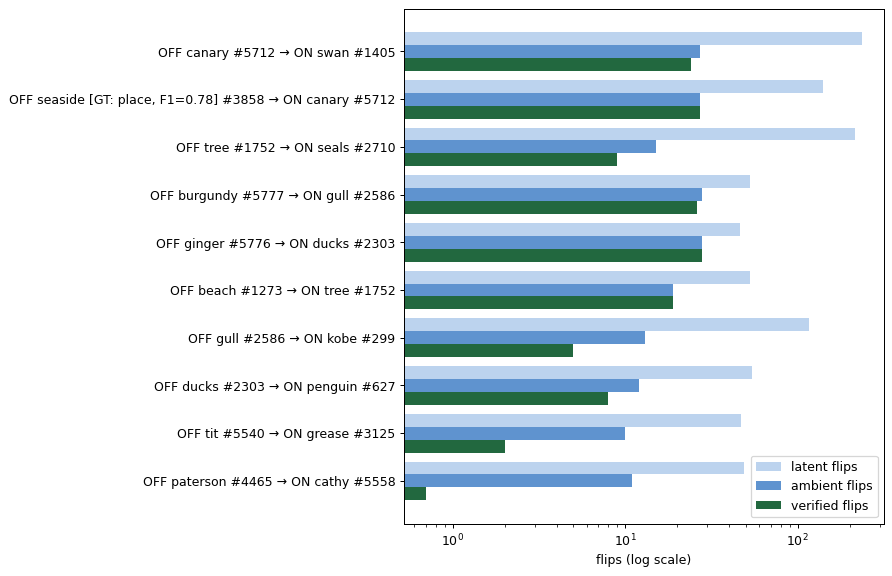

In [14]:
results = torch.load(run_dir / "sweep_results.pt", weights_only=False)
index = {e["direction_idx"]: e for e in json.load(open(run_dir / "successful_flips" / "index.json"))}
short = lambda n: re.sub(r"\s*\(SAE #(\d+)\)", r" #\1", str(n)).replace("  ->  ", " → ")

rows = results[:10][::-1]
y_pos = np.arange(len(rows)); h = 0.27
fig, ax = plt.subplots(figsize=(10, 0.55 * len(rows) + 1))
for label, key, color, off in (("latent flips", "latent_flip_count", "#bcd3ee", h),
                               ("ambient flips", "ambient_flip_count", "#5f93cf", 0),
                               ("verified flips", "success_count", "#22683f", -h)):
    ax.barh(y_pos + off, [max(r[key] or 0, 0.7) for r in rows], height=h, color=color, label=label)
ax.set_yticks(y_pos); ax.set_yticklabels([short(r["dimension_name"]) for r in rows])
ax.set_xscale("log"); ax.set_xlabel("flips (log scale)"); ax.legend(loc="lower right")
plt.tight_layout(); show(fig)

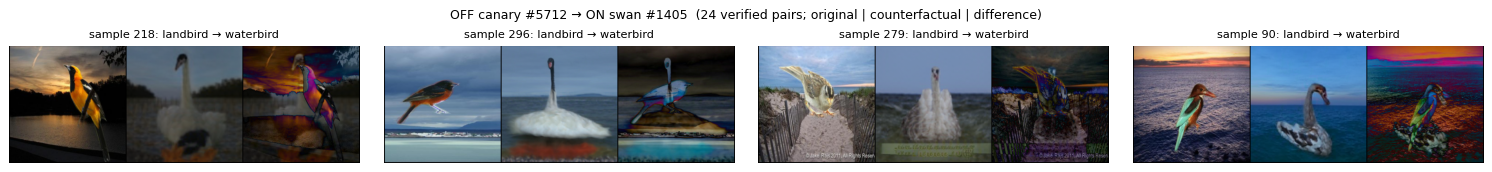

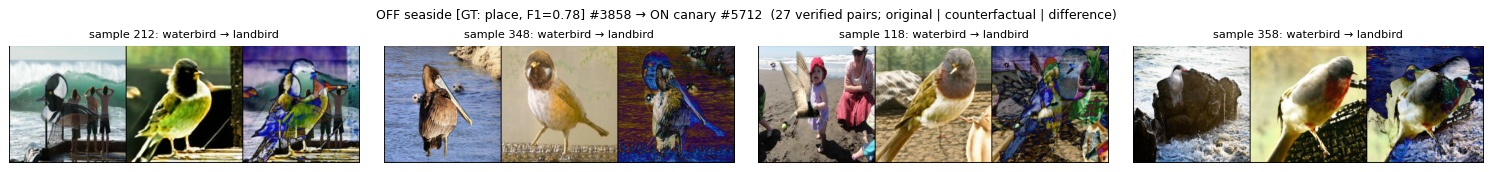

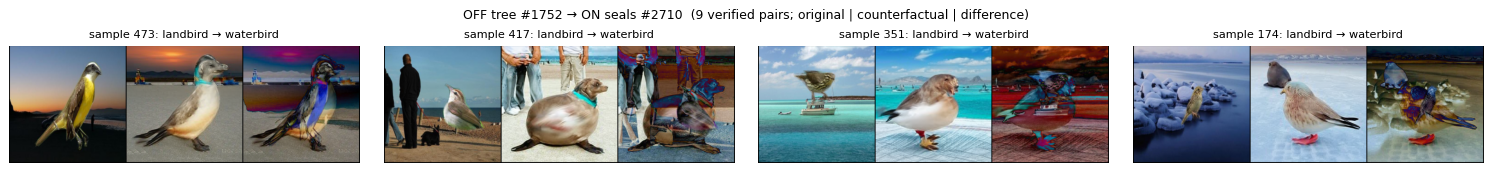

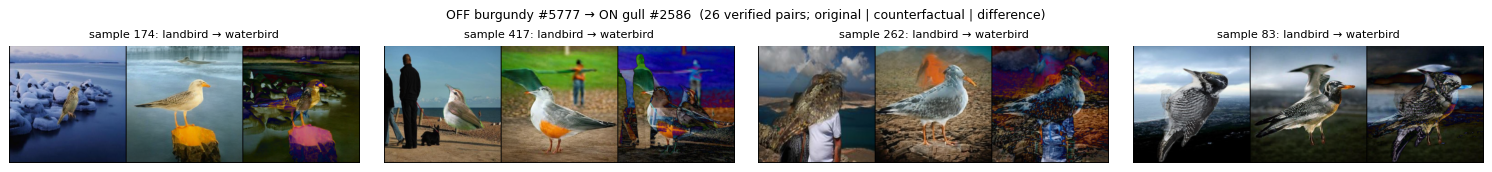

In [15]:
from PIL import Image

def show_pairs(direction_idx, n=4):
    e = index[direction_idx]
    pairs = e["pairs"][:n]
    fig, axes = plt.subplots(1, len(pairs), figsize=(4.2 * len(pairs), 1.9))
    for ax, p in zip(np.atleast_1d(axes), pairs):
        ax.imshow(Image.open(run_dir / "successful_flips" / e["folder"] / p["file"]))
        ax.set_title(f"sample {p['sample_idx']}: {['landbird', 'waterbird'][p['orig_class']]} → "
                     f"{['landbird', 'waterbird'][p['target_class']]}", fontsize=9)
        ax.axis("off")
    fig.suptitle(f"{short(e['name'])}  ({e['n_verified']} verified pairs; original | counterfactual | difference)", fontsize=10)
    plt.tight_layout(); show(fig)

for r in results[:4]:
    if r["direction_idx"] in index:
        show_pairs(r["direction_idx"])

## 7. Your verdicts

For each direction decide: did the edit change what makes a landbird a landbird or a waterbird a
waterbird (**true**), or something the classifier should not rely on (**false**, spurious)?

### Option A (default): let Waterbirds' metadata suggest them

Only possible because Waterbirds labels the background: a direction that switches a **background
concept** — one that tracks the background (`place`) clearly better than the bird class — is a
shortcut. For every concept we measure the AUC of its activation for `place` and for `y` on
validation images, rescaled to 0 (no relation) … 1 (perfect); a concept counts as background when
its `place` relation is at least 0.3 and larger than its class relation. A concept pair is spurious
if either of its two concepts is a background concept.

In [16]:
import clip
from sklearn.metrics import roc_auc_score
from torch.utils.data import Subset

dictionary = get_sparse_dictionary(dictionary_config, device="cuda")
clip_model, _ = clip.load("ViT-L/14", device="cuda")
clip_mean = torch.tensor((0.48145466, 0.4578275, 0.40821073), device="cuda").view(1, 3, 1, 1)
clip_std = torch.tensor((0.26862954, 0.26130258, 0.27577711), device="cuda").view(1, 3, 1, 1)
_, val_groups, _ = get_datasets(data_config, task_config=group_task)
sample = np.random.default_rng(0).choice(len(val_groups), 800, replace=False).tolist()
C, Y, P = [], [], []
for x, t in DataLoader(Subset(val_groups, sample), batch_size=64, num_workers=4):
    with torch.no_grad():
        x224 = torch.nn.functional.interpolate(x.cuda(), 224, mode="bicubic").clamp(0, 1)
        C.append(dictionary.encode(clip_model.encode_image((x224 - clip_mean) / clip_std).float()).float().cpu())
    Y.append(t[:, 0]); P.append(t[:, 1])
C, Y, P = torch.cat(C).numpy(), torch.cat(Y).numpy(), torch.cat(P).numpy()
assoc = lambda atom, labels: abs(roc_auc_score(labels, C[:, atom]) - 0.5) * 2 if C[:, atom].any() else 0.0

verdicts, table = {}, []
for d_idx, e in index.items():
    atoms = [int(a) for a in re.findall(r"SAE #(\d+)", e["name"])]
    rel = [(vocabulary[a], assoc(a, P), assoc(a, Y)) for a in atoms]
    background = [name for name, p, c in rel if p >= 0.3 and p > c]
    verdicts[d_idx] = "false" if background else "true"
    table.append((short(e["name"]), e["n_verified"],
                  ", ".join(f"{n}: {p:.2f} / {c:.2f}" for n, p, c in rel), ", ".join(background), verdicts[d_idx]))
del clip_model, dictionary; torch.cuda.empty_cache()
pd.DataFrame(table, columns=["direction", "verified pairs", "concept: background / class relation",
                             "background concepts", "verdict"])

Loading config from n_components=6144 dict_size=None sparse_dictionaries_type='MSAEDecomposition' category='sparse_dictionaries' base_path=None name=None run_name=None weights_path=None act_size=512 visualizations_per_component=100 weights_name='weights.npz' batch_size=1024 component_strings=None data=None fitted_on_encoder=None clip_model='clip:ViT-L/14' ckpt_url='https://huggingface.co/WolodjaZ/MSAE/resolve/main/ViT-L_14/centered/6144_768_TopKReLU_64_RW_False_False_0.0_cc3m_ViT-L~14_train_image_2905936_768.pth' interp_url='https://huggingface.co/WolodjaZ/MSAE/resolve/main/ViT-L_14/centered/Concept_Interpreter_6144_768_TopKReLU_64_RW_False_False_0.0_cc3m_ViT-L~14_train_image_2905936_768_disect_ViT-L~14_-1_text_20000_768.npy' local_dir='/tmp/msae_weights' vocab_filename='clip_disect_20k.txt' activation='TopKReLU_64' use_matryoshka=False lr=0.0005 epochs=20


[MSAE] Loaded MSAE with 6144 directions mapped to concepts.


Loading config from config_name='DataConfig' input_type='image' output_type='singleclass' input_size=[3, 256, 256] output_size=[2] dataset_path='/data/datasets/waterbirds' dataset_origin_path=None num_samples=None dataset_class='WaterbirdsDataset' split=[] has_hints=False normalization=None invariances=[] output_split=None downsize=None confounding_factors=['y', 'place'] foreground=None background=None confounder_probability=None full_confounder_config=None class_ratios=None seed=0 label_noise=None set_negative_to_zero=True font_path=None delimiter=',' crop_size=None inverse=None label_rel_path='data.csv' x_selection='img_filename' in_memory=False spray_label_file=None spray_groups_balanced=False generator=None diffusion_augmented=False sampling_time_fraction=0.3 num_discretization_steps=20 batch_wise_augmentation=True tabular_preprocessing=None


instantiate waterbirds dataset!


instantiate waterbirds dataset!


instantiate waterbirds dataset!


,direction,verified pairs,concept: background / class relation,background concepts,verdict
0,OFF canary #5712 → ON swan #1405,24,"canary: 0.13 / 0.73, swan: 0.03 / 0.07",,true
1,OFF tree #1752 → ON seals #2710,9,"tree: 0.75 / 0.21, seals: 0.01 / 0.00",tree,false
2,"OFF seaside [GT: place, F1=0.78] #3858 → ON ca...",27,"seaside: 0.58 / 0.19, canary: 0.13 / 0.73",seaside,false
3,OFF gull #2586 → ON kobe #299,5,"gull: 0.08 / 0.42, kobe: 0.00 / 0.00",,true
4,OFF ducks #2303 → ON penguin #627,8,"ducks: 0.04 / 0.24, penguin: 0.01 / 0.02",,true
5,OFF beach #1273 → ON tree #1752,19,"beach: 0.23 / 0.01, tree: 0.75 / 0.21",tree,false
6,OFF burgundy #5777 → ON gull #2586,26,"burgundy: 0.03 / 0.22, gull: 0.08 / 0.42",,true
7,OFF tit #5540 → ON grease #3125,2,"tit: 0.05 / 0.14, grease: 0.00 / 0.00",,true
8,OFF ginger #5776 → ON ducks #2303,28,"ginger: 0.04 / 0.07, ducks: 0.04 / 0.24",,true


### Option B: judge them yourself

Look at the pairs from step 6 (`show_pairs(direction_idx)`) and write your verdicts into the dict;
`"true"`, `"false"`, or leave a direction out to ignore it.

In [17]:
JUDGE_MYSELF = False
if JUDGE_MYSELF:
    verdicts = {
        # direction_idx: "true" | "false",
    }
print({short(index[d]["name"]): v for d, v in verdicts.items()})

{'OFF canary #5712 → ON swan #1405': 'true', 'OFF tree #1752 → ON seals #2710': 'false', 'OFF seaside [GT: place, F1=0.78] #3858 → ON canary #5712': 'false', 'OFF gull #2586 → ON kobe #299': 'true', 'OFF ducks #2303 → ON penguin #627': 'true', 'OFF beach #1273 → ON tree #1752': 'false', 'OFF burgundy #5777 → ON gull #2586': 'true', 'OFF tit #5540 → ON grease #3125': 'true', 'OFF ginger #5776 → ON ducks #2303': 'true'}


## 8. Correct the classifier: refit only the last layer (DFR)

*Deep feature reweighting* (Kirichenko et al., 2023) keeps the network frozen and retrains only its
final linear layer. We fit it — an L2 logistic regression, a convex problem — on the penultimate
features of

* the training and validation images with their labels, and
* the verified counterfactuals: those of a **false** direction keep their *original* class (the
  spurious edit must not change the prediction), those of a **true** direction get the *target*
  class.

The regularisation strength is chosen by 5-fold cross-validation. It takes seconds; the features
are computed once. (The web demo offers the same with an SVM or closed-form ridge solver as well; a
full finetuning of the network through CFKD is also available in PEAL but much slower.)

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

train_g, val_g, _ = get_datasets(data_config, task_config=group_task)
F_train, y_train, _ = predict_features(student, train_g)
F_val, y_val, _ = predict_features(student, val_g)

cf_images, cf_labels, cf_kind = [], [], []
for d_idx, verdict in verdicts.items():
    e = index[d_idx]
    for p in e["pairs"]:
        img = Image.open(run_dir / "successful_flips" / e["folder"] / p["file"].replace("_pair", "_cf", 1)).convert("RGB")
        img = img.resize(tuple(data_config.input_size[1:][::-1]))
        cf_images.append(torch.from_numpy(np.asarray(img, dtype=np.float32) / 255).permute(2, 0, 1))
        cf_labels.append(p["orig_class"] if verdict == "false" else p["target_class"]); cf_kind.append(verdict)
with torch.no_grad():
    F_cf = torch.cat([student(torch.stack(cf_images[i:i + 64]).cuda(), return_latents=True)[0].float().cpu()
                      for i in range(0, len(cf_images), 64)]).numpy()
y_cf, cf_kind = np.array(cf_labels), np.array(cf_kind)
print(f"{len(y_cf)} counterfactuals, {int((cf_kind == 'false').sum())} from spurious directions")

X = np.concatenate([F_train, F_val, F_cf]); y = np.concatenate([y_train, y_val, y_cf])
is_cf = np.r_[np.zeros(len(y_train) + len(y_val), bool), np.ones(len(y_cf), bool)]
mu, sd = X[~is_cf].mean(0), X[~is_cf].std(0) + 1e-6
Xs = (X - mu) / sd
weight = np.where(is_cf, 0.5 * (~is_cf).sum() / max(is_cf.sum(), 1), 1.0)   # counterfactuals: 1/3 of the weight

def cv_score(C_reg):
    scores = []
    for tr, te in StratifiedKFold(5, shuffle=True, random_state=0).split(Xs, y * 2 + is_cf):
        clf = LogisticRegression(C=C_reg, class_weight="balanced", max_iter=3000).fit(Xs[tr], y[tr], sample_weight=weight[tr])
        pred, orig = clf.predict(Xs[te]), ~is_cf[te]
        balanced = np.mean([(pred[orig & (y[te] == k)] == k).mean() for k in (0, 1)])
        consistent = (pred[~orig] == y[te][~orig]).mean() if (~orig).any() else balanced
        scores.append((balanced + consistent) / 2)
    return float(np.mean(scores))

C_best = max((0.001, 0.01, 0.1, 1.0), key=cv_score)
clf = LogisticRegression(C=C_best, class_weight="balanced", max_iter=3000).fit(Xs, y, sample_weight=weight)
coef = clf.coef_[0] / sd
intercept = clf.intercept_[0] - (clf.coef_[0] * mu / sd).sum()
print("chosen C:", C_best)

# write it into the model: two logits whose softmax equals the fitted sigmoid
new_last = torch.nn.Linear(coef.shape[0], 2, bias=True)
new_last.weight.data = torch.tensor(np.stack([-coef / 2, coef / 2]), dtype=torch.float32)
new_last.bias.data = torch.tensor([-intercept / 2, intercept / 2], dtype=torch.float32)
after = group_report((F_test @ new_last.weight.data.numpy().T + new_last.bias.data.numpy()).argmax(1), y_test, place_test)
student.fc = new_last.cuda()          # TorchvisionModel keeps its head in .fc (see get_last_layer())
after.index = ["after DFR"]
pd.concat([before, after])

Loading config from config_name='DataConfig' input_type='image' output_type='singleclass' input_size=[3, 256, 256] output_size=[2] dataset_path='/data/datasets/waterbirds' dataset_origin_path=None num_samples=None dataset_class='WaterbirdsDataset' split=[] has_hints=False normalization=None invariances=[] output_split=None downsize=None confounding_factors=['y', 'place'] foreground=None background=None confounder_probability=None full_confounder_config=None class_ratios=None seed=0 label_noise=None set_negative_to_zero=True font_path=None delimiter=',' crop_size=None inverse=None label_rel_path='data.csv' x_selection='img_filename' in_memory=False spray_label_file=None spray_groups_balanced=False generator=None diffusion_augmented=False sampling_time_fraction=0.3 num_discretization_steps=20 batch_wise_augmentation=True tabular_preprocessing=None


instantiate waterbirds dataset!


instantiate waterbirds dataset!


instantiate waterbirds dataset!


148 counterfactuals, 55 from spurious directions


chosen C: 0.01


,landbird on land,landbird on water,waterbird on land,waterbird on water,overall,average group,worst group
before,0.999,0.898,0.802,0.960,0.933,0.915,0.802
after DFR,0.996,0.896,0.911,0.966,0.945,0.942,0.896


The **worst group** is the number to watch: a model that stopped relying on the background gets the
birds right on either background.

Save the corrected model like any PEAL predictor; `export_to_onnx` writes an ONNX copy.

In [19]:
from peal.architectures.onnx_predictor import export_to_onnx

corrected = WORK / "dinov3_linear_probe_dfr"
corrected.mkdir(parents=True, exist_ok=True)
torch.save(student, corrected / "model.cpl")
print("saved", corrected / "model.cpl")
EXPORT_ONNX = False
if EXPORT_ONNX:
    export_to_onnx(student.cpu(), str(corrected / "model.onnx"), input_shape=data_config.input_size)

saved /data/notebook_runs/waterbirds_tour/dinov3_linear_probe_dfr/model.cpl


## Where next

* **The same without code:** the web demo (`peal/web`, see `deploy/spark/README.md`) takes an ONNX
  model and a zip of images and runs steps 5–8 with a feedback page.
* **The same from the command line:** `python run_didae.py --config <run_dir>/config.yaml`.
* **Other adaptors and explainers:** CFKD with SCE counterfactuals (notebooks 01 and 02), full
  finetuning instead of DFR (`finetune_iterations: 1`), other datasets from the registry
  (`peal/registry.py`).